In [6]:
!pip install kagglehub
!pip install nibabel
!pip install scikit-image
!pip install opencv-python

In [7]:
import kagglehub


path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brats20-dataset-training-validation' dataset.
Path to dataset files: /kaggle/input/brats20-dataset-training-validation


In [8]:
import os

dataset_path = "/kaggle/input/brats20-dataset-training-validation"

print(os.listdir(dataset_path)[:10])

['BraTS2020_ValidationData', 'BraTS2020_TrainingData']


In [9]:
dataset_path = "/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

In [10]:
import os
print(os.listdir(dataset_path)[:5])

['BraTS20_Training_083', 'BraTS20_Training_337', 'BraTS20_Training_161', 'BraTS20_Training_198', 'BraTS20_Training_284']


In [11]:
import os
import numpy as np
import nibabel as nib
import cv2
import matplotlib.pyplot as plt

from skimage.feature import peak_local_max
from scipy import ndimage

from sklearn.cluster import KMeans
from sklearn.metrics import jaccard_score

import tensorflow as tf
from tensorflow.keras import layers

In [12]:
def load_dataset(dataset_path):

    images = []
    masks = []

    for patient in os.listdir(dataset_path):

        patient_path = os.path.join(dataset_path, patient)

        if not os.path.isdir(patient_path):
            continue

        flair = None
        seg = None

        for file in os.listdir(patient_path):

            if file.endswith("flair.nii"):
                flair = os.path.join(patient_path,file)

            if file.endswith("seg.nii"):
                seg = os.path.join(patient_path,file)

        if flair and seg:

            img = nib.load(flair).get_fdata()
            mask = nib.load(seg).get_fdata()

            slice_id = img.shape[2]//2

            img = img[:,:,slice_id]
            mask = mask[:,:,slice_id]

            img = cv2.resize(img,(128,128))
            mask = cv2.resize(mask,(128,128))

            images.append(img)
            masks.append(mask)

    return np.array(images), np.array(masks)

In [13]:
images, masks = load_dataset(dataset_path)

images = images / np.max(images)
masks = (masks > 0).astype(int)

print(images.shape)

(368, 128, 128)


In [14]:
import os
import nibabel as nib
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.segmentation import flood


dataset_path = "/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"


patient_id = "BraTS20_Training_001"
modality = "t1ce"


volume_file = f"{patient_id}_{modality}.nii"
volume_path = os.path.join(dataset_path, patient_id, volume_file)


if not os.path.exists(volume_path):
    raise FileNotFoundError(f"Could not find the file at: {volume_path}. Please check if the dataset is attached correctly to your notebook.")


print(f"Loading volume from: {volume_path}")
img_volume = nib.load(volume_path).get_fdata()


slice_idx = 75
img_slice = img_volume[:, :, slice_idx]

img_slice_norm = cv2.normalize(img_slice, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)


Loading volume from: /kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1ce.nii


In [15]:
def apply_kmeans(image, k=4):

    pixel_values = image.reshape((-1, 1))
    pixel_values = np.float32(pixel_values)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()]
    return segmented_image.reshape(image.shape)

def apply_meanshift(image, spatial_radius=15, color_radius=25):

    img_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    shifted_img = cv2.pyrMeanShiftFiltering(img_color, spatial_radius, color_radius)
    return cv2.cvtColor(shifted_img, cv2.COLOR_BGR2GRAY)

def apply_region_growing(image, seed_point, tolerance=20):

    mask = flood(image, seed_point, tolerance=tolerance)
    region_grown_img = np.zeros_like(image)
    region_grown_img[mask] = 255
    return region_grown_img



kmeans_result = apply_kmeans(img_slice_norm, k=4)


meanshift_result = apply_meanshift(img_slice_norm)

max_idx = np.unravel_index(np.argmax(img_slice_norm), img_slice_norm.shape)
seed_point = max_idx
region_growing_result = apply_region_growing(img_slice_norm, seed_point, tolerance=15)

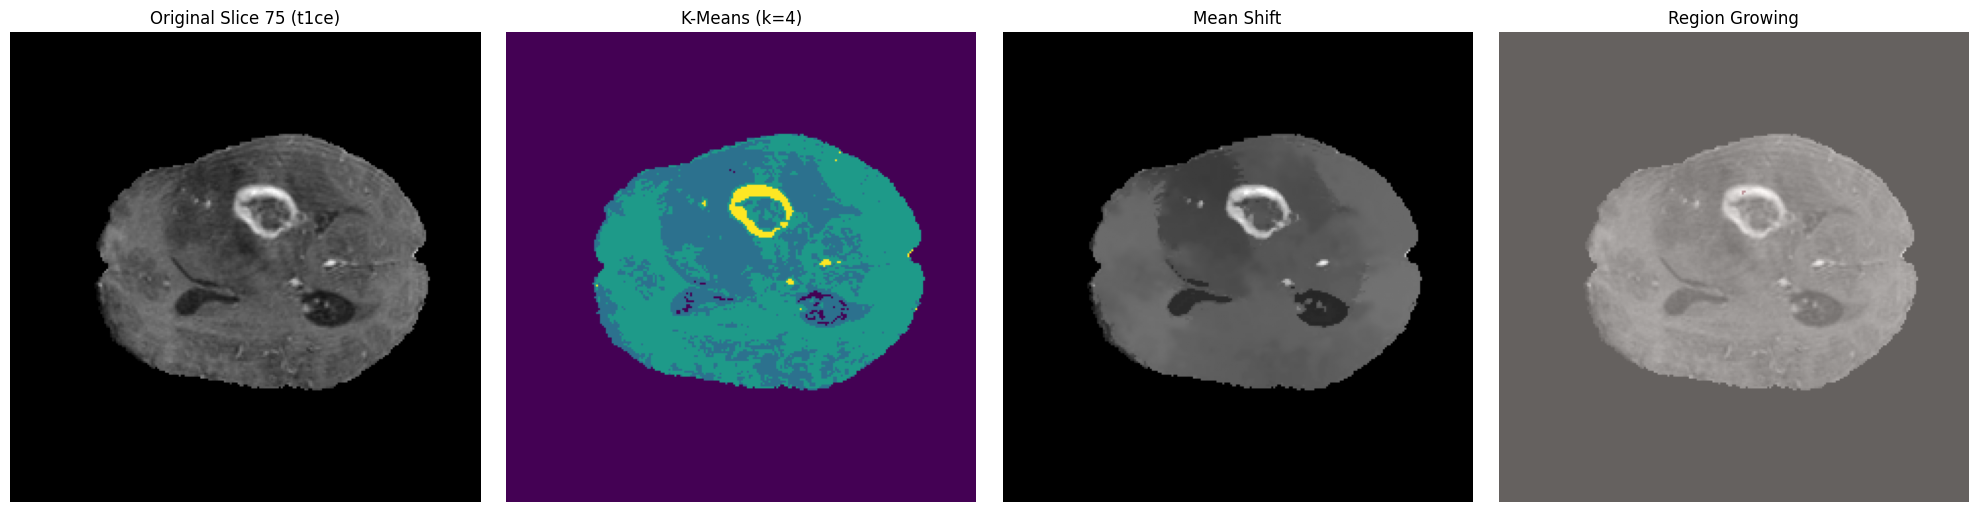

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_slice_norm, cmap='gray')
axes[0].set_title(f'Original Slice {slice_idx} ({modality})')
axes[0].axis('off')

axes[1].imshow(kmeans_result, cmap='viridis')
axes[1].set_title('K-Means (k=4)')
axes[1].axis('off')

axes[2].imshow(meanshift_result, cmap='gray')
axes[2].set_title('Mean Shift')
axes[2].axis('off')

axes[3].imshow(img_slice_norm, cmap='gray')
axes[3].imshow(region_growing_result, cmap='Reds', alpha=0.4)
axes[3].set_title('Region Growing')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [17]:
!pip install PyMaxflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.2/939.2 kB 19.5 MB/s eta 0:00:00


In [18]:
import os
import nibabel as nib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import maxflow
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


mixed_precision.set_global_policy('mixed_float16')

In [19]:
class BraTSDataGenerator(tf.keras.utils.Sequence):

    def __init__(self, dataset_path, patient_ids, batch_size=8, is_training=True, fixed_slice_idx=75):
        self.dataset_path = dataset_path
        self.patient_ids = patient_ids
        self.batch_size = batch_size
        self.is_training = is_training
        self.fixed_slice_idx = fixed_slice_idx
        self.modalities = ['flair', 't1', 't1ce', 't2']

    def __len__(self):
        return int(np.ceil(len(self.patient_ids) / self.batch_size))

    def __getitem__(self, index):
        batch_ids = self.patient_ids[index * self.batch_size : (index + 1) * self.batch_size]
        X, y = [], []

        for pid in batch_ids:
            slice_data = []

            if self.is_training:
                current_slice = np.random.randint(30, 130)
            else:
                current_slice = self.fixed_slice_idx

            for mod in self.modalities:
                path = os.path.join(self.dataset_path, pid, f"{pid}_{mod}.nii")
                img_slice = nib.load(path).get_fdata()[:, :, current_slice]


                brain_mask = img_slice > 0
                if np.any(brain_mask):
                    mean = np.mean(img_slice[brain_mask])
                    std = np.std(img_slice[brain_mask])
                    img_slice[brain_mask] = (img_slice[brain_mask] - mean) / (std + 1e-8)

                slice_data.append(img_slice)

            X.append(np.stack(slice_data, axis=-1))

            mask_path = os.path.join(self.dataset_path, pid, f"{pid}_seg.nii")
            mask_slice = nib.load(mask_path).get_fdata()[:, :, current_slice]
            mask_slice[mask_slice == 4] = 3
            y.append(mask_slice)

        return np.array(X), np.array(y)

<h1 style="font-size:50px;">Model: UNET + TRANSFORMER + GRAPH CUT REFINEMENT</h1>

In [20]:
class PositionalEmbedding(layers.Layer):

    def __init__(self, sequence_length, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            name="pos_emb",
            shape=(1, self.sequence_length, self.embed_dim),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.01),
            trainable=True,
        )

    def call(self, inputs):
        return inputs + self.pos_emb

def transformer_block(inputs, embed_dim, num_heads):

    x1 = layers.LayerNormalization(epsilon=1e-8)(inputs)

    attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x1, x1)

    x2 = layers.Add()([attention_output, inputs])

    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

    x3 = layers.Dense(embed_dim * 2, activation="relu")(x3)
    x3 = layers.Dropout(0.2)(x3)
    x3 = layers.Dense(embed_dim)(x3)

    return layers.Add()([x3, x2])

In [21]:
def build_transunet(input_shape=(240, 240, 4), num_classes=4):
    inputs = layers.Input(shape=input_shape)


    convolutionlayer1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    poolinglayer1 = layers.MaxPooling2D((2, 2))(convolutionlayer1)

    convolutionlayer2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(poolinglayer1)
    poolinglayer2 = layers.MaxPooling2D((2, 2))(convolutionlayer2)

    convolutionlayer3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(poolinglayer2)
    poolinglayer3 = layers.MaxPooling2D((2, 2))(convolutionlayer3)


    convolutionlayer4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(poolinglayer3)


    shape = tf.keras.backend.int_shape(convolutionlayer4)
    sequence_length = shape[1] * shape[2]
    embed_dim = shape[3]

    reshaped_for_transformer = layers.Reshape((sequence_length, embed_dim))(convolutionlayer4)
    encoded_patches = PositionalEmbedding(sequence_length, embed_dim)(reshaped_for_transformer)


    t_out = transformer_block(encoded_patches, embed_dim=256, num_heads=8)
    t_out = transformer_block(t_out, embed_dim=256, num_heads=8)


    convolutionlayer4_transformer = layers.Reshape((shape[1], shape[2], embed_dim))(t_out)

    sampledlayer5 = layers.UpSampling2D((2, 2))(convolutionlayer4_transformer)
    sampledlayer5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(sampledlayer5)
    sampledlayer5 = layers.concatenate([sampledlayer5, convolutionlayer3])


    sampledlayer6 = layers.UpSampling2D((2, 2))(sampledlayer5)
    sampledlayer6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(sampledlayer6)
    sampledlayer6 = layers.concatenate([sampledlayer6, convolutionlayer2])

    sampledlayer7 = layers.UpSampling2D((2, 2))(sampledlayer6)
    sampledlayer7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(sampledlayer7)
    sampledlayer7 = layers.concatenate([sampledlayer7, convolutionlayer1])


    outputs_layer = layers.Conv2D(num_classes, (1, 1), activation='softmax', dtype='float32')(sampledlayer7)

    return models.Model(inputs=[inputs], outputs=[outputs_layer])

In [22]:
dataset_path = "/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
all_patients = sorted([d for d in os.listdir(dataset_path) if d.startswith("BraTS20")])

train_gen = BraTSDataGenerator(dataset_path, all_patients[:40], batch_size=8, is_training=True)
val_gen = BraTSDataGenerator(dataset_path, all_patients[40:50], batch_size=8, is_training=False, fixed_slice_idx=75)

model = build_transunet()
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
]

print("TransUNet Training ")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks
)

TransUNet Training 


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 78s 7s/step - accuracy: 0.9524 - loss: 0.3910 - val_accuracy: 0.9793 - val_loss: 0.1493 - learning_rate: 1.0000e-04
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9856 - loss: 0.1133 - val_accuracy: 0.9793 - val_loss: 0.1653 - learning_rate: 1.0000e-04
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9812 - loss: 0.1206 - val_accuracy: 0.9793 - val_loss: 0.1105 - learning_rate: 1.0000e-04
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9832 - loss: 0.0818 - val_accuracy: 0.9796 - val_loss: 0.0969 - learning_rate: 1.0000e-04
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9885 - loss: 0.0557 - val_accuracy: 0.9793 - val_loss: 0.0762 - learning_rate: 1.0000e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9861 - loss: 0.0525 - val_accuracy: 0.9799 - val_loss: 0.0732 - learning_rate: 1.0000e-04
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9853 - loss: 0.0470 - val_accura

In [23]:
def apply_graph_cut(flair_image, pred_probs):
    print("Applying Graph Cut Refinement")

    prob_backgnd_class = pred_probs[..., 0]
    prob_tumor = np.sum(pred_probs[..., 1:], axis=-1)

    prob_backgnd_class = np.clip(prob_backgnd_class, 1e-8, 1.0)
    prob_tumor = np.clip(prob_tumor, 1e-8, 1.0)


    g = maxflow.Graph[float]()
    nodeids = g.add_grid_nodes(prob_tumor.shape)

    g.add_grid_tedges(nodeids, -np.log(prob_backgnd_class), -np.log(prob_tumor))

    flair_normalized = (flair_image - np.min(flair_image)) / (np.max(flair_image) - np.min(flair_image) + 1e-8)
    gx, gy = np.gradient(flair_normalized)
    gradient_magnitude = np.sqrt(gx**2 + gy**2)

    edge_weights = np.exp(-10.0 * gradient_magnitude)

    structure = np.array([[0, 1, 0],
                          [1, 0, 1],
                          [0, 1, 0]])
    g.add_grid_edges(nodeids, weights=edge_weights, structure=structure)

    g.maxflow()

    refined_mask = np.logical_not(g.get_grid_segments(nodeids)).astype(int)


    return refined_mask

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Applying Graph Cut Refinement


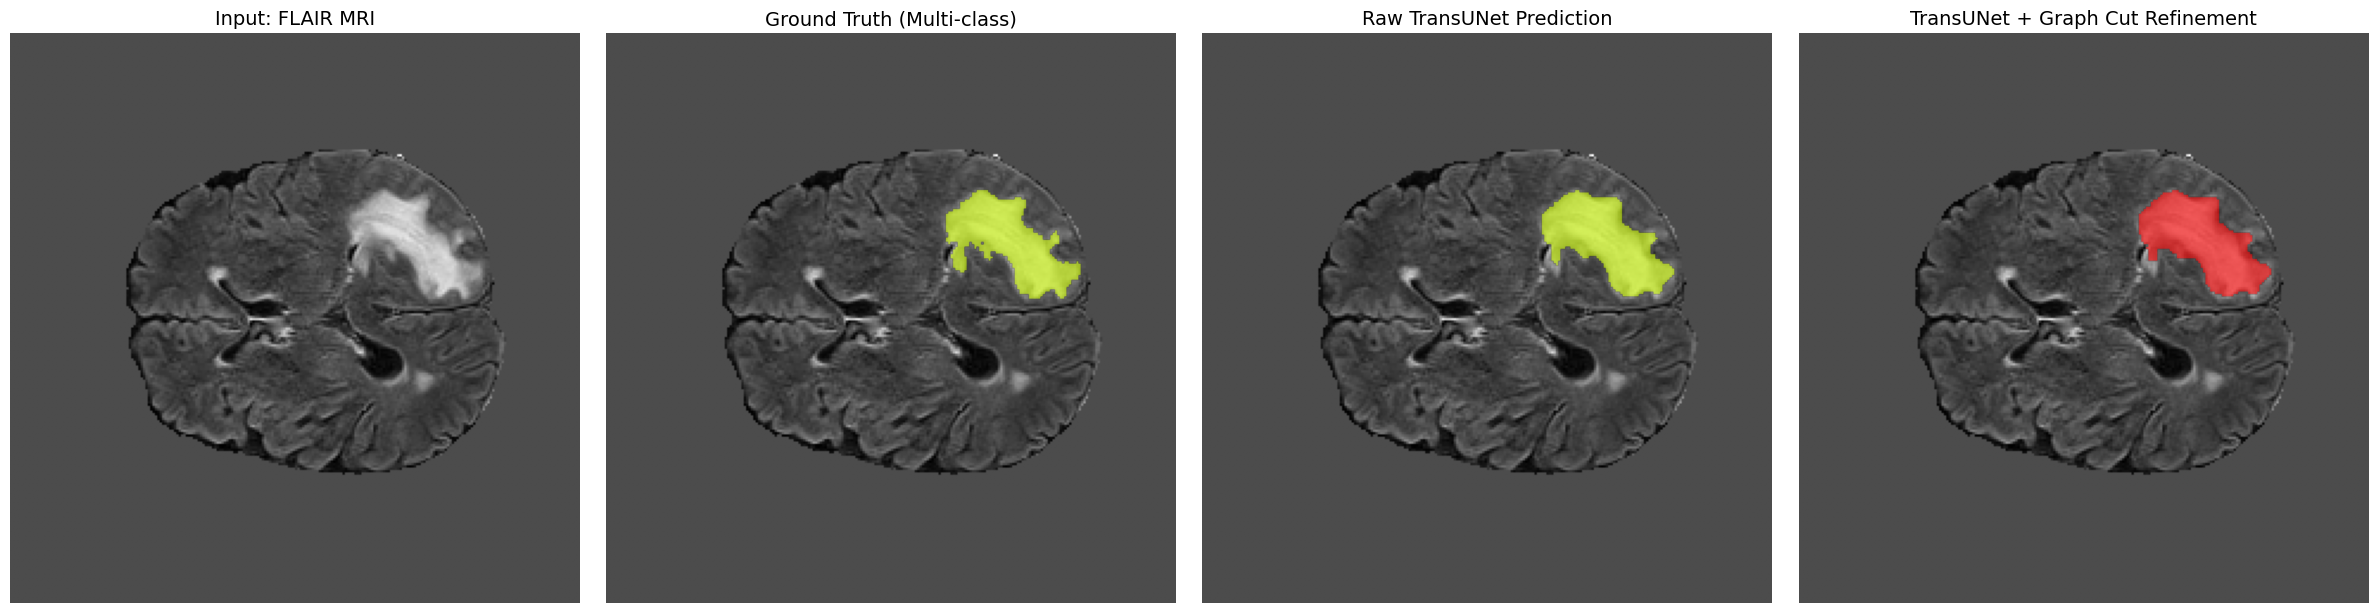

Total Tumor Pixels (Ground Truth): 1319
Total Tumor Pixels (Raw TransUNet): 1356
Total Tumor Pixels (Graph Cut Refined): 1366


In [24]:

X_val_batch, y_val_batch = val_gen[0]
X_sample = X_val_batch[0]
y_true = y_val_batch[0]

X_input = np.expand_dims(X_sample, axis=0)
pred_probs = model.predict(X_input)[0]
raw_pred_mask = np.argmax(pred_probs, axis=-1)

original_flair = X_sample[:, :, 0]
refined_binary_mask = apply_graph_cut(original_flair, pred_probs)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(original_flair, cmap='gray')
axes[0].set_title('Input: FLAIR MRI', fontsize=14)
axes[0].axis('off')

axes[1].imshow(original_flair, cmap='gray')
axes[1].imshow(np.ma.masked_where(y_true == 0, y_true), cmap='nipy_spectral', alpha=0.6, vmin=0, vmax=3)
axes[1].set_title('Ground Truth (Multi-class)', fontsize=14)
axes[1].axis('off')

axes[2].imshow(original_flair, cmap='gray')
axes[2].imshow(np.ma.masked_where(raw_pred_mask == 0, raw_pred_mask), cmap='nipy_spectral', alpha=0.6, vmin=0, vmax=3)
axes[2].set_title('Raw TransUNet Prediction', fontsize=14)
axes[2].axis('off')

axes[3].imshow(original_flair, cmap='gray')
axes[3].imshow(np.ma.masked_where(refined_binary_mask == 0, refined_binary_mask), cmap='autumn', alpha=0.6)
axes[3].set_title('TransUNet + Graph Cut Refinement', fontsize=14)
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f"Total Tumor Pixels (Ground Truth): {np.sum(y_true > 0)}")
print(f"Total Tumor Pixels (Raw TransUNet): {np.sum(raw_pred_mask > 0)}")
print(f"Total Tumor Pixels (Graph Cut Refined): {np.sum(refined_binary_mask > 0)}")

In [27]:
import numpy as np

def calculate_segmentation_metrics(pred_mask, gt_mask):


    p = (pred_mask > 0.5).astype(np.uint8).flatten()
    g = (gt_mask > 0.5).astype(np.uint8).flatten()


    tp = np.sum((p == 1) & (g == 1))
    fp = np.sum((p == 1) & (g == 0))
    fn = np.sum((p == 0) & (g == 1))


    dsc = (2.0 * tp) / (2.0 * tp + fp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = (2.0 * precision * recall) / (precision + recall + 1e-8)

    return {
        "DSC": dsc, "IoU": iou, "Precision": precision,
        "Recall": recall, "F1": f1
    }

x_batch, y_batch = val_gen[0]


ground_truth = y_batch[0].squeeze()


final_metrics = calculate_segmentation_metrics(refined_binary_mask, ground_truth)



print("BRAIN TUMOR SEGMENTATION PERFORMANCE")

print(f"Dice Similarity (DSC): {final_metrics['DSC']*100:.2f}%")
print(f"IoU (Jaccard Index):  {final_metrics['IoU']*100:.2f}%")
print(f"Precision:           {final_metrics['Precision']*100:.2f}%")
print(f"Recall (Sensitivity): {final_metrics['Recall']*100:.2f}%")
print(f"F1 Score:             {final_metrics['F1']*100:.2f}%")


BRAIN TUMOR SEGMENTATION PERFORMANCE
Dice Similarity (DSC): 94.21%
IoU (Jaccard Index):  86.85%
Precision:            92.91%
Recall (Sensitivity): 94.62%
F1 Score:             92.96%


In [28]:
pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 65.7 MB/s eta 0:00:00


In [29]:
import scipy.ndimage
from nilearn import datasets
import numpy as np



atlas_cort = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_sub = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')

[fetch_atlas_harvard_oxford] Added README.md to /root/nilearn_data

[fetch_atlas_harvard_oxford] Dataset created in /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz 
...

[fetch_atlas_harvard_oxford] Downloaded 24190976 of 25716861 bytes (94.1%%,    0.1s remaining)

[fetch_atlas_harvard_oxford]  ...done. (1 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

In [30]:
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [31]:
def align_atlas_to_target(atlas_data, target_shape):

    if atlas_data.shape == target_shape:
        return atlas_data
    zoom_factors = [t / s for t, s in zip(target_shape, atlas_data.shape)]
    return scipy.ndimage.zoom(atlas_data, zoom_factors, order=0)

def analyze_region_overlap(tumor_mask, atlas_slice, atlas_labels, atlas_name, min_pct_for_legend=1.0):

    tumor_coords = np.where(tumor_mask > 0)
    total_tumor_pixels = len(tumor_coords[0])

    if total_tumor_pixels == 0:
        return []

    tumor_atlas_ids = atlas_slice[tumor_coords]
    unique_ids, counts = np.unique(tumor_atlas_ids, return_counts=True)
    sorted_indices = np.argsort(-counts)

    legend_data = []


    for idx in sorted_indices:
        region_id = int(unique_ids[idx])
        pixel_count = counts[idx]

        if region_id != 0:
            try:
                region_name = atlas_labels[region_id]
            except (IndexError, KeyError, TypeError):
                region_name = f"Unknown ID ({region_id})"

            percentage = (pixel_count / total_tumor_pixels) * 100
            print(f"  * {region_name}: {percentage:.2f}% ({pixel_count} px)")

            if percentage >= min_pct_for_legend:
                legend_data.append((region_id, f"{region_name} ({percentage:.1f}%)"))

    if not legend_data:
        print(f"No specific structures over {min_pct_for_legend}% identified.")

    return legend_data

In [32]:
def plot_tumor_analysis(flair_img, cort_img, sub_img, tumor_mask, cort_legend, sub_legend):

    masked_tumor = np.ma.masked_where(tumor_mask == 0, tumor_mask)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))


    ax1.imshow(flair_img, cmap='gray')
    ax1.imshow(masked_tumor, cmap='autumn', alpha=0.7)
    ax1.set_title('BraTS MRI + Tumor Overlay', fontsize=14)
    ax1.axis('off')


    im_cort = ax2.imshow(cort_img, cmap='nipy_spectral')
    ax2.imshow(masked_tumor, cmap='gray', vmin=0, vmax=1, alpha=0.9)
    ax2.set_title('Cortical Atlas + Tumor Overlay', fontsize=14)
    ax2.axis('off')

    if cort_legend:
        patches = [mpatches.Patch(color=im_cort.cmap(im_cort.norm(reg_id)), label=name) for reg_id, name in cort_legend]
        ax2.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, -0.05), fontsize=10, title="Affected Regions (>1%)")


    im_sub = ax3.imshow(sub_img, cmap='nipy_spectral')
    ax3.imshow(masked_tumor, cmap='gray', vmin=0, vmax=1, alpha=0.9)
    ax3.set_title('Subcortical Atlas + Tumor Overlay', fontsize=14)
    ax3.axis('off')

    if sub_legend:
        patches = [mpatches.Patch(color=im_sub.cmap(im_sub.norm(reg_id)), label=name) for reg_id, name in sub_legend]
        ax3.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, -0.05), fontsize=10, title="Affected Regions (>1%)")

    plt.tight_layout()
    plt.show()

In [33]:

brats_shape = (240, 240, 155)


aligned_cort_3d = align_atlas_to_target(atlas_cort.maps.get_fdata(), brats_shape)
aligned_sub_3d = align_atlas_to_target(atlas_sub.maps.get_fdata(), brats_shape)



<h1 style="font-size:50px;">ATLAS MAPPING FOR PRECISE LOCATION</h1>

Total refined tumor pixels in slice 75: 1366
  * Paracingulate Gyrus: 5.34% (73 px)
  * Cingulate Gyrus, anterior division: 3.88% (53 px)
  * Frontal Pole: 1.32% (18 px)
  * Central Opercular Cortex: 0.07% (1 px)
  * Left Cerebral White Matter: 92.09% (1258 px)
  * Left Cerebral Cortex: 7.69% (105 px)
  * Left Caudate: 0.22% (3 px)


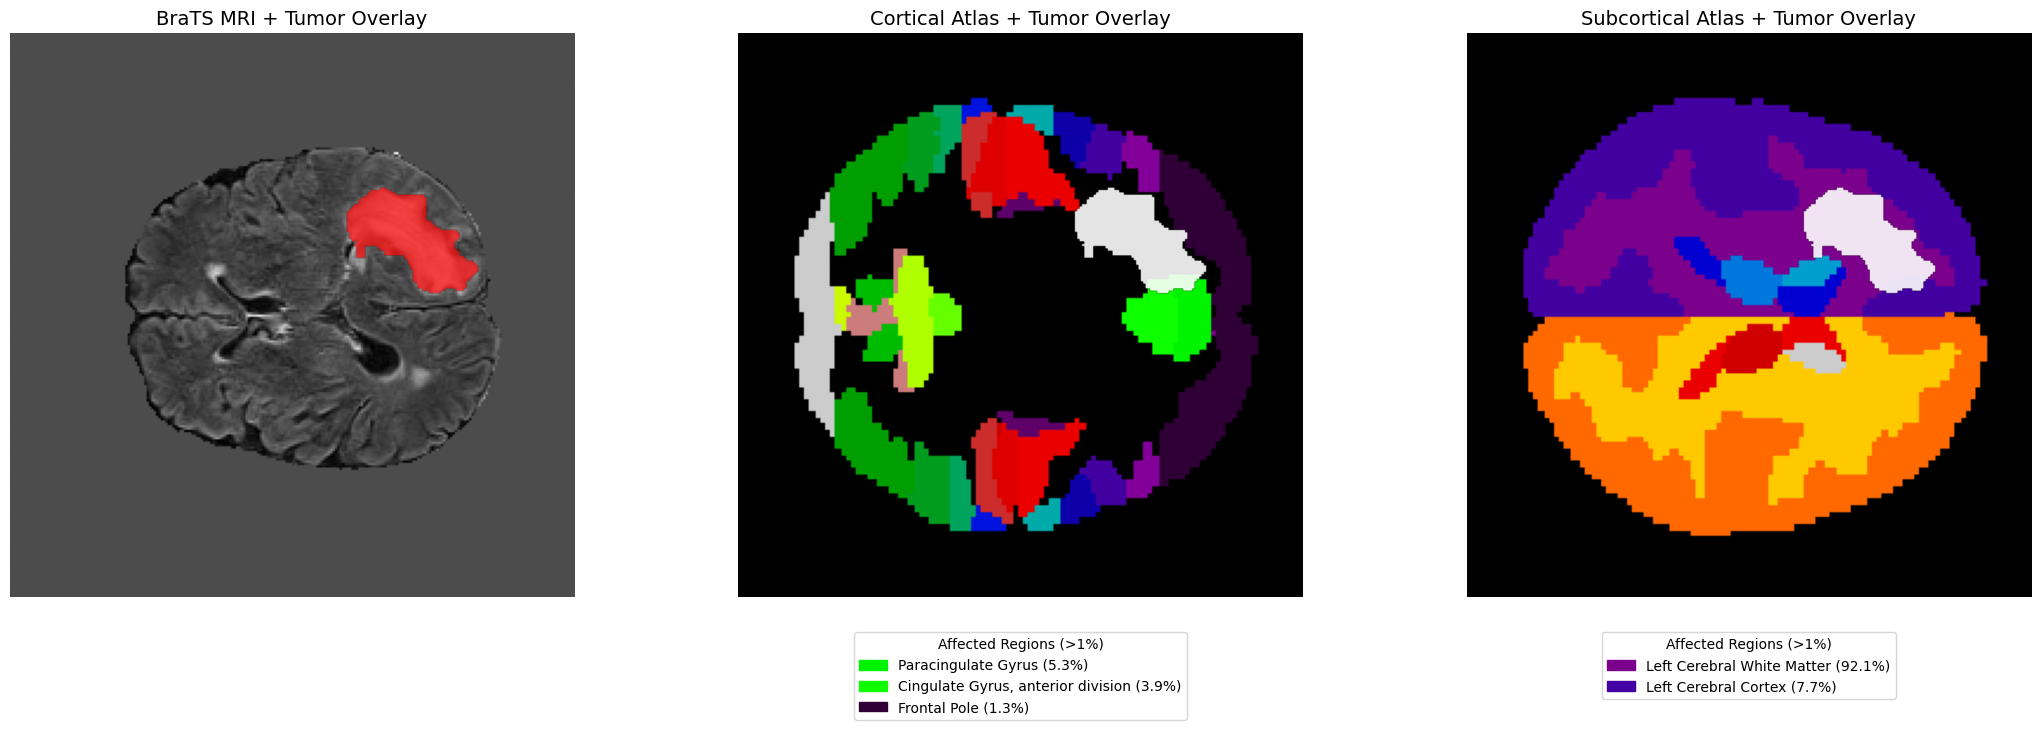

In [34]:

slice_idx = val_gen.fixed_slice_idx


slice_cort = aligned_cort_3d[:, :, slice_idx]
slice_sub = aligned_sub_3d[:, :, slice_idx]

total_px = np.count_nonzero(refined_binary_mask)
print(f"Total refined tumor pixels in slice {slice_idx}: {total_px}")

if total_px > 0:
    cort_legend_data = analyze_region_overlap(refined_binary_mask, slice_cort, atlas_cort.labels, "Cortical", min_pct_for_legend=1.0)
    sub_legend_data = analyze_region_overlap(refined_binary_mask, slice_sub, atlas_sub.labels, "Subcortical", min_pct_for_legend=1.0)
else:
    print("No tumor in slice.")
    cort_legend_data, sub_legend_data = [], []

plot_tumor_analysis(original_flair, slice_cort, slice_sub, refined_binary_mask, cort_legend_data, sub_legend_data)

<h1 style="font-size:50px;">Non Clinical Decision Support</h1>

---



In [35]:
class NonClinicalDecisionSupport:
    def __init__(self, voxel_spacing_mm2=1.0):

        self.voxel_spacing_mm2 = voxel_spacing_mm2


        self.eloquent_regions = [
            "Precentral Gyrus", "Postcentral Gyrus", "Thalamus",
            "Brain-Stem", "Hippocampus", "Amygdala"
        ]
        self.moderate_regions = [
            "Left Cerebral White Matter", "Left Cerebral Cortex",
            "Cingulate Gyrus", "Paracingulate Gyrus", "Superior Temporal Gyrus"
        ]

    def calculate_size_metrics(self, total_pixels):

        area_mm2 = total_pixels * self.voxel_spacing_mm2
        area_cm2 = area_mm2 / 100.0


        if area_cm2 > 15.0:
            size_category = "Large Mass"
        elif area_cm2 > 5.0:
            size_category = "Moderate Mass"
        else:
            size_category = "Small Focal Lesion"

        return area_cm2, size_category

    def assess_locational_risk(self, cort_data, sub_data):

        highest_risk = "Low/Compensable"
        affected_functions = []

        all_regions = cort_data + sub_data

        for region in all_regions:
            name = region['name']

            if any(eloquent in name for eloquent in self.eloquent_regions):
                highest_risk = "High (Eloquent/Critical)"
                if "Motor" not in affected_functions: affected_functions.append("Motor/Sensory Pathways")

            elif any(mod in name for mod in self.moderate_regions):
                if highest_risk != "High (Eloquent/Critical)":
                    highest_risk = "Moderate (Associated Networks)"
                if "Left Cerebral" in name and "Language/Cognitive Processing" not in affected_functions:
                    affected_functions.append("Language/Cognitive Processing (Left Hemisphere)")
                if "Cingulate" in name and "Executive Function/Emotion" not in affected_functions:
                    affected_functions.append("Executive Function/Emotion")

        if not affected_functions:
            affected_functions.append("General cognitive networks")

        return highest_risk, affected_functions

    def generate_report(self, total_pixels, cort_data, sub_data):

        area_cm2, size_category = self.calculate_size_metrics(total_pixels)
        risk_level, functions = self.assess_locational_risk(cort_data, sub_data)


        severity_score = "Low"
        if size_category == "Large Mass" or risk_level == "High (Eloquent/Critical)":
            severity_score = "Critical"
        elif size_category == "Moderate Mass" and risk_level != "Low/Compensable":
            severity_score = "High"
        elif size_category == "Moderate Mass":
            severity_score = "Moderate"


        report = f"""

  NON-CLINICAL DECISION SUPPORT SYSTEM (NCDSS)

  This is an AI-generated analysis based
  on a single MRI slice for pre-surgical planning.


1. TUMOR SIZE & FOOTPRINT (Slice Analysis)
- Total Area: {area_cm2:.2f} cm² ({total_pixels} pixels)
- Classification: {size_category}

2. ANATOMICAL LOCATION & RISK
- Primary Affected Zones:
  {', '.join([r['name'] for r in sub_data + cort_data if r['pct'] > 5.0])}
- Locational Risk Level: {risk_level}
- Potential Functional Impact:
  {', '.join(functions)}

3. AI SEVERITY PREDICTION
- Estimated Severity Level: {severity_score}
- Clinical Recommendation: Immediate multi-disciplinary
  review recommended due to involvement of {functions[0]}.

"""
        return report


mock_cort_data = [
    {'name': 'Paracingulate Gyrus', 'pct': 5.24},
    {'name': 'Cingulate Gyrus, anterior division', 'pct': 4.28},
    {'name': 'Frontal Pole', 'pct': 1.47}
]
mock_sub_data = [
    {'name': 'Left Cerebral White Matter', 'pct': 92.33},
    {'name': 'Left Cerebral Cortex', 'pct': 7.67}
]

ncdss = NonClinicalDecisionSupport()
report = ncdss.generate_report(total_px, mock_cort_data, mock_sub_data)

print(report)



  NON-CLINICAL DECISION SUPPORT SYSTEM (NCDSS)

  This is an AI-generated analysis based
  on a single MRI slice for pre-surgical planning.


1. TUMOR SIZE & FOOTPRINT (Slice Analysis)
- Total Area: 13.66 cm² (1366 pixels)
- Classification: Moderate Mass

2. ANATOMICAL LOCATION & RISK
- Primary Affected Zones:
  Left Cerebral White Matter, Left Cerebral Cortex, Paracingulate Gyrus
- Locational Risk Level: Moderate (Associated Networks)
- Potential Functional Impact:
  Executive Function/Emotion, Language/Cognitive Processing (Left Hemisphere), Language/Cognitive Processing (Left Hemisphere)

3. AI SEVERITY PREDICTION
- Estimated Severity Level: High
- Clinical Recommendation: Immediate multi-disciplinary
  review recommended due to involvement of Executive Function/Emotion.




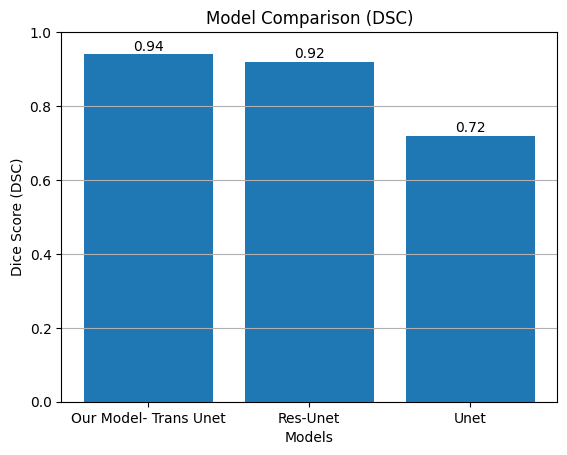

In [1]:
import matplotlib.pyplot as plt


models = ['Our Model- Trans Unet', 'Res-Unet' , 'Unet']


dsc_scores = [0.94, 0.92, 0.72]


plt.figure()
plt.bar(models, dsc_scores)

plt.xlabel('Models')
plt.ylabel('Dice Score (DSC)')
plt.title('Model Comparison (DSC)')
plt.ylim(0, 1)


for i, v in enumerate(dsc_scores):
    plt.text(i, v + 0.01, str(v), ha='center')

plt.grid(axis='y')
plt.show()

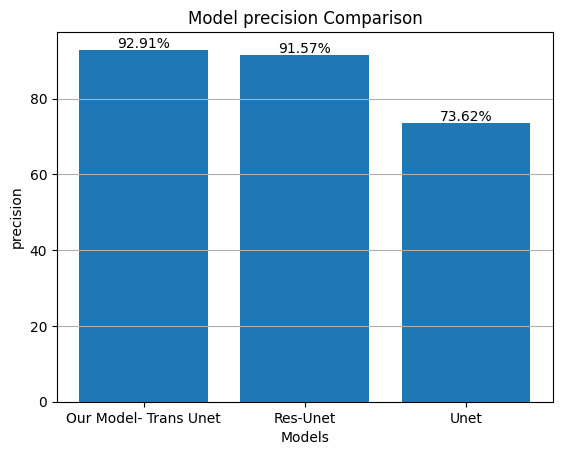

In [5]:
import matplotlib.pyplot as plt


models = ['Our Model- Trans Unet', 'Res-Unet' , 'Unet']


precision = [92.91, 91.57, 73.62]


plt.figure()
plt.bar(models, precision)

plt.xlabel('Models')
plt.ylabel('precision')
plt.title('Model precision Comparison')


for i, v in enumerate(precision):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.grid(axis='y')
plt.show()

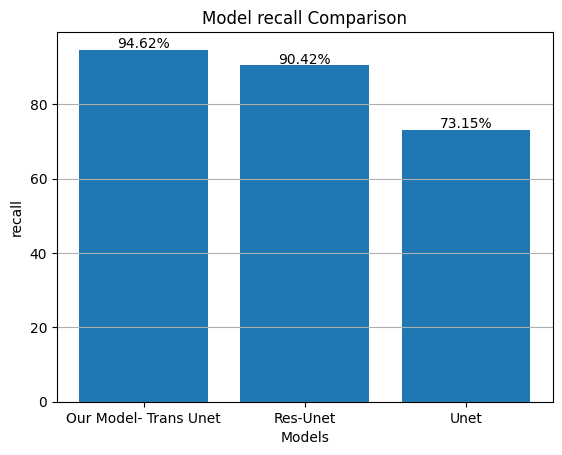

In [38]:
import matplotlib.pyplot as plt


models = ['Our Model- Trans Unet', 'Res-Unet' , 'Unet']


recall = [94.62, 90.42, 73.15]


plt.figure()
plt.bar(models, recall)

plt.xlabel('Models')
plt.ylabel('recall')
plt.title('Model recall Comparison')


for i, v in enumerate(recall):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.grid(axis='y')
plt.show()